# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1

### Running a sample script

In [2]:
# Sample student study data
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'exam_score': [52, 55, 59, 63, 68, 72, 75, 81]
}

# Create DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['hours_studied']]
y = df['exam_score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.20


In [4]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [55, 72]
Predicted scores: [np.float64(55.4), np.float64(71.8)]


In [5]:
r_squared = model.score(X_test, y_test)

print(f'R² score: {r_squared:.3f}')

R² score: 0.999


The R² score measures how much of the variation in exam scores is explained by the model.

An R² score closer to 1 means the model fits the data very well and makes accurate predictions. 
A lower score means the model does not explain the relationship as effectively.

This model has a strong fit because the predicted scores are close to the actual scores.

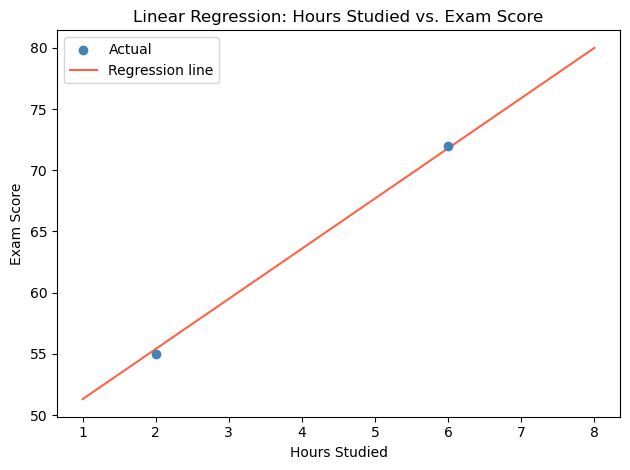

In [17]:
# Scatter plot: actual test data points
plt.scatter(
    X_test,
    y_test,
    color='steelblue',
    label='Actual',
    zorder=3
)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

x_new = pd.DataFrame({'hours_studied': [1, 8]})
y_pred = model.predict(x_new)

plt.plot(
    x_range,
    y_line,
    color='tomato',
    label='Regression line'
)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')

plt.legend()
plt.tight_layout()
plt.show()

The scatter plot shows that the actual data points follow the regression line closely. 
This indicates a strong positive relationship between hours studied and exam scores.

As study hours increase, exam scores also tend to increase. The regression line represents 
the model’s prediction of this trend.

## Lab 2

### Building your own model

In [7]:
ad_data = {
    'monthly_ad_spend': [
        500, 1000, 1500, 2000, 2500,
        3000, 3500, 4000, 4500, 5000,
        5500, 6000, 6500, 7000, 7500,
        8000, 8500, 9000, 9500, 10000
    ],

    'monthly_revenue': [
        4200, 5100, 6800, 7400, 8900,
        9200, 10500, 11800, 12400, 13100,
        14200, 15600, 15900, 17200, 18100,
        19400, 20200, 21500, 22100, 23800
    ]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [8]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print('Shape of X2:', X2.shape)
print('Shape of y2:', y2.shape)

Shape of X2: (20, 1)
Shape of y2: (20,)


In [9]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [10]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [11]:
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

# Interpretation:
# For each additional $1 spent on advertising,
# the predicted monthly revenue increases by about
# model2.coef_[0] dollars.

Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [12]:
y2_pred = model2.predict(X2_test)

print('Actual Revenue\tPredicted Revenue')

for actual, predicted in zip(y2_test, y2_pred):
    print(f'{actual}\t\t{predicted:.2f}')

Actual Revenue	Predicted Revenue
4200		4603.85
21500		21229.03
19400		19273.13
5100		5581.80


In [13]:
r2_score = model2.score(X2_test, y2_test)

print(f'R² score: {r2_score:.3f}')

R² score: 0.998


The R² score shows how much of the variation in monthly revenue
is explained by monthly advertising spend.

A score close to 1 means the model fits the data very well.
This model appears to be a strong fit because the predictions
are close to the actual values.

The model explains a very high percentage of the variation in revenue,
which suggests that ad spend has a strong relationship with revenue.

### Visualizing the results

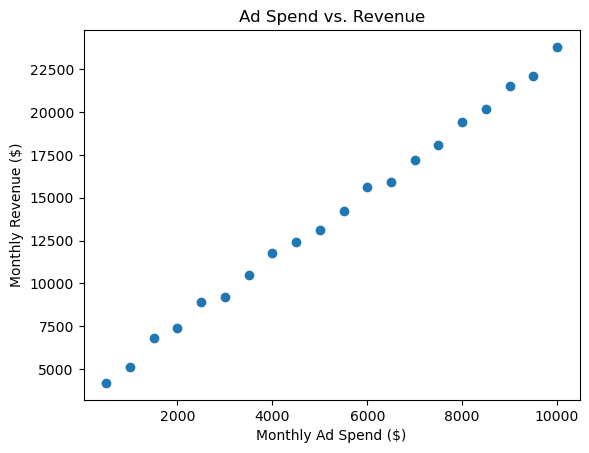

In [14]:
plt.scatter(
    X2,
    y2
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

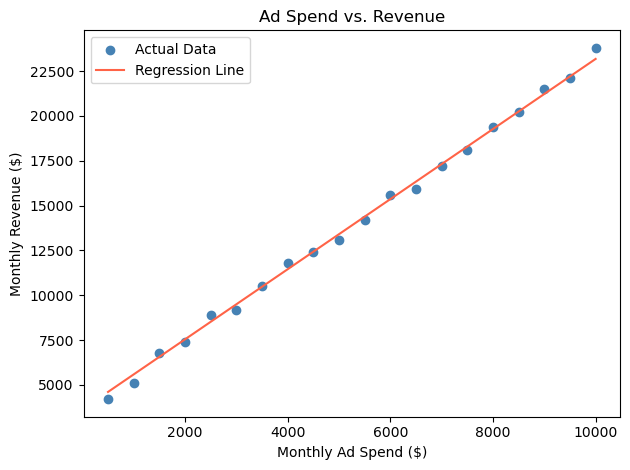

In [18]:
# Scatter plot
plt.scatter(
    X2,
    y2,
    color='steelblue',
    label='Actual Data'
)

# Regression line
x2_range = pd.DataFrame({
    'monthly_ad_spend': np.linspace(
        X2['monthly_ad_spend'].min(),
        X2['monthly_ad_spend'].max(),
        100
    )
})

y2_line = model2.predict(x2_range)
y2_line = model2.predict(x2_range)

plt.plot(
    x2_range,
    y2_line,
    color='tomato',
    label='Regression Line'
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.legend()

plt.tight_layout()
plt.show()

The regression line appears to fit the data very well because
most of the data points are close to the line.

This matches the R² score, which showed that the model explains
most of the variation in monthly revenue. The strong linear pattern
suggests a positive relationship between advertising spend and revenue.